In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
from google.colab import files
uploaded = files.upload()

Saving raw data1.csv to raw data1.csv


In [11]:
df = pd.read_csv("raw data1.csv")
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03-02-2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21-04-2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21-09-2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24-08-2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24-03-2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [9]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            114 non-null    int64  
 1   Sale_Date             114 non-null    object 
 2   Sales_Rep             114 non-null    object 
 3   Region                114 non-null    object 
 4   Sales_Amount          114 non-null    float64
 5   Quantity_Sold         114 non-null    int64  
 6   Product_Category      114 non-null    object 
 7   Unit_Cost             114 non-null    float64
 8   Unit_Price            114 non-null    float64
 9   Customer_Type         114 non-null    object 
 10  Discount              114 non-null    float64
 11  Payment_Method        114 non-null    object 
 12  Sales_Channel         114 non-null    object 
 13  Region_and_Sales_Rep  114 non-null    object 
dtypes: float64(4), int64(2), object(8)
memory usage: 12.6+ KB


,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,1050.789474,4768.395439,26.798246,2667.271404,2913.306140,0.136140
std,29.649120,2836.308611,13.607117,1302.471746,1316.058667,0.080689
min,1001.000000,113.400000,1.000000,121.190000,267.220000,0.000000
25%,1022.500000,2574.300000,16.250000,1593.442500,1841.640000,0.062500
50%,1053.500000,4632.695000,28.500000,2746.425000,2953.420000,0.135000
75%,1075.750000,7349.270000,39.000000,3698.585000,3956.300000,0.200000
max,1100.000000,9914.150000,49.000000,4904.930000,5166.720000,0.300000


In [10]:
df.isnull().sum()

,0
Product_ID,0
Sale_Date,0
Sales_Rep,0
Region,0
Sales_Amount,0
Quantity_Sold,0
Product_Category,0
Unit_Cost,0
Unit_Price,0
Customer_Type,0


**🔎Descriptive Statistics & Univariate Analysis**

In [12]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,1050.789474,4768.395439,26.798246,2667.271404,2913.306140,0.136140
std,29.649120,2836.308611,13.607117,1302.471746,1316.058667,0.080689
min,1001.000000,113.400000,1.000000,121.190000,267.220000,0.000000
25%,1022.500000,2574.300000,16.250000,1593.442500,1841.640000,0.062500
50%,1053.500000,4632.695000,28.500000,2746.425000,2953.420000,0.135000
75%,1075.750000,7349.270000,39.000000,3698.585000,3956.300000,0.200000
max,1100.000000,9914.150000,49.000000,4904.930000,5166.720000,0.300000


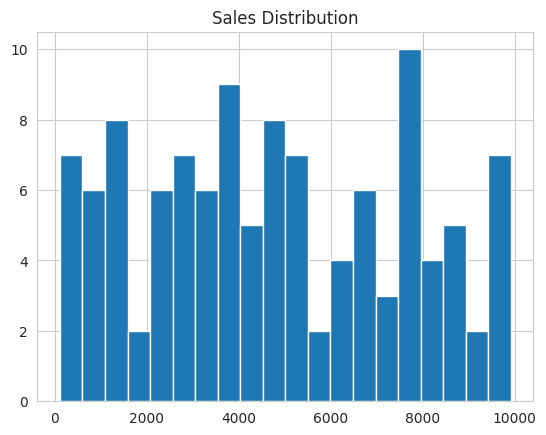

In [17]:
plt.figure()
plt.hist(df['Sales_Amount'], bins=20)
plt.title("Sales Distribution")
plt.show()

In [18]:
df['Region'].value_counts()

,count
Region,
East,34
West,29
South,27
North,24


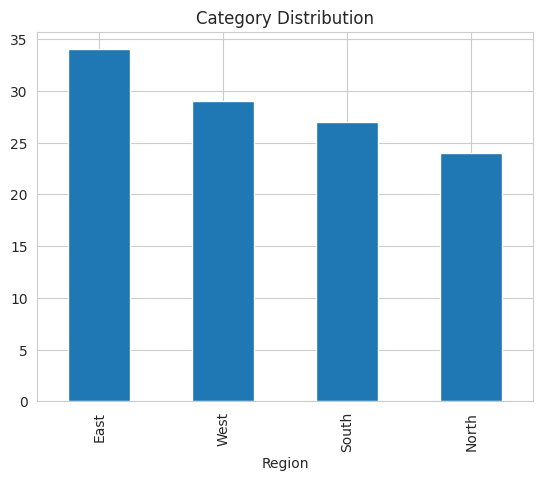

In [19]:
plt.figure()
df['Region'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

📊 **Business Questions**

What are top 5 products by revenue?

In [35]:
top_products = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False).head(5)
top_products

,Sales_Amount
Product_Category,
Furniture,155454.72
Clothing,150536.19
Electronics,119274.31
Food,118331.86


Which category has highest sales?

In [36]:
df.groupby('Region')['Sales_Amount'].sum().sort_values(ascending=False)

,Sales_Amount
Region,
East,160779.16
South,140205.30
West,128102.85
North,114509.77


which Region Generating Highest unit cost?

In [45]:
top_city = df.groupby("Region")["Unit_Cost"].sum().sort_values(ascending=False).head(1)
top_city

,Unit_Cost
Region,
East,91871.5


Average Order Value (AOV)

In [52]:
average_order_value = df["Sales_Amount"].mean()

average_order_value

np.float64(4768.395438596492)

Which Month Had Highest Sales?

In [56]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], dayfirst=True)
df["Month"] = df["Sale_Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Sales_Amount"].sum()

highest_month = monthly_sales.sort_values(ascending=False).head(1)

highest_month

,Sales_Amount
Month,
2023-11,82767.96


Top 5 Sales Representatives by Total Sales

In [57]:
top_sales_rep = (
    df.groupby("Sales_Rep")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_sales_rep

,Sales_Amount
Sales_Rep,
David,138799.03
Eve,125355.07
Bob,116693.08
Alice,81730.33
Charlie,81019.57


**Using SQL Database**

In [23]:
import sqlite3

In [24]:
conn = sqlite3.connect(":memory:")
df.to_sql("data_table", conn, index=False, if_exists="replace")

114

**View 1st 5 records**

In [25]:
query = "SELECT * FROM data_table LIMIT 5;"
pd.read_sql(query, conn)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03-02-2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21-04-2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21-09-2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24-08-2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24-03-2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


**Count Total Rows**

In [26]:
query = "SELECT COUNT(*) AS total_rows FROM data_table;"
pd.read_sql(query, conn)

,total_rows
0,114


**Check Distinct Values**

In [28]:
query = "SELECT DISTINCT Quantity_Sold FROM data_table;"
pd.read_sql(query, conn)

,Quantity_Sold
0,18
1,17
2,30
3,39
4,13
5,32
6,29
7,46
8,43
9,21


**Group By Analysis**

In [32]:
query = """
SELECT Product_Category, COUNT(*) AS total
FROM data_table
GROUP BY Product_Category
ORDER BY total DESC;
"""
pd.read_sql(query, conn)

,Product_Category,total
0,Furniture,38
1,Clothing,29
2,Electronics,25
3,Food,22


**Find Average Value**

In [33]:
query = """
SELECT AVG(Unit_Cost) AS average_value
FROM data_table;
"""
pd.read_sql(query, conn)

,average_value
0,2667.271404


**🔥 Multivariate Analysis & Correlation**

In [63]:
numeric_cols = ['Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount']

corr_matrix = df[numeric_cols].corr()
corr_matrix

,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
Sales_Amount,1.000000,0.088804,0.163979,0.167212,-0.001052
Quantity_Sold,0.088804,1.000000,-0.100858,-0.072419,0.020966
Unit_Cost,0.163979,-0.100858,1.000000,0.993975,0.071043
Unit_Price,0.167212,-0.072419,0.993975,1.000000,0.059636
Discount,-0.001052,0.020966,0.071043,0.059636,1.000000


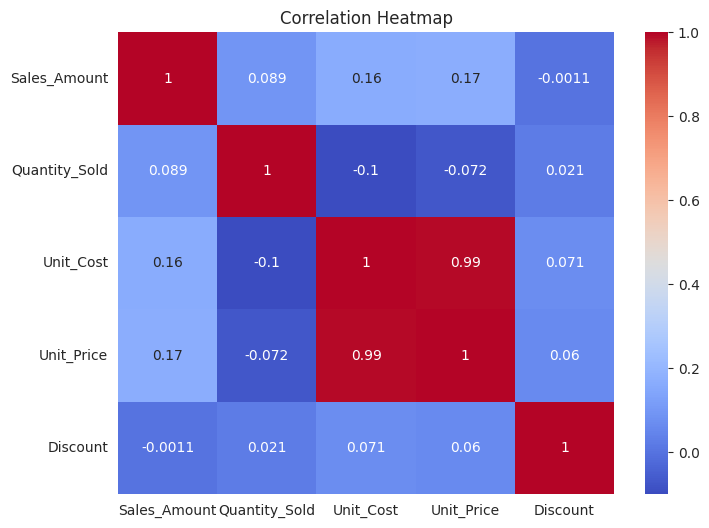

In [64]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Multivariate Analysis (Pairplot)

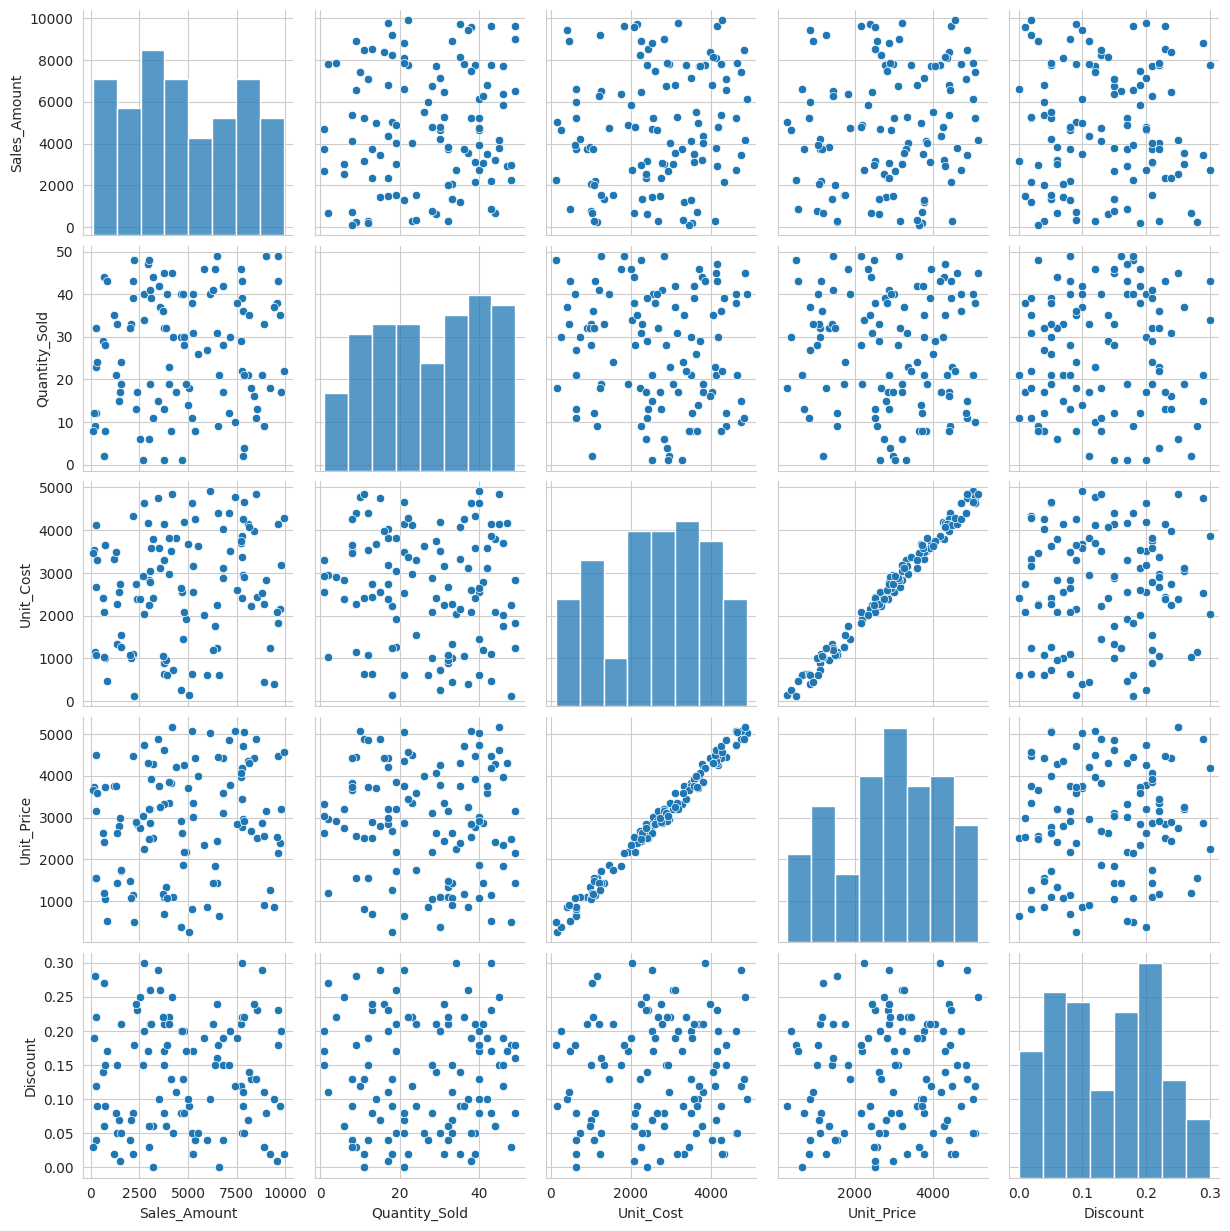

In [65]:
sns.pairplot(df[numeric_cols])
plt.show()

After running correlation, write observations like:

Example Observations (You will adjust based on output)

Strong positive correlation between Unit_Price and Sales_Amount

Moderate relationship between Quantity_Sold and Sales_Amount

Weak correlation between Discount and Sales_Amount

Unit_Cost and Unit_Price highly correlated (pricing strategy)

**Final Conclusion**

There is a strong positive relationship between Unit Price and Sales Amount, indicating that higher priced products generate higher revenue.
Discount has a weak negative correlation with Sales Amount, suggesting discount strategy needs optimization.
Quantity Sold moderately impacts Sales Amount.